# Boosting With AdaBoost
In this notebook, we will explain what Boosting is, and will use the AdaBoostClassifier to improve the results of a DecisionTreeClassifier. We will compare results between using just a decision tree classifier, and boosting with AdaBoost

The project will follow three phases:
1. Data Preprocessing
2. Model Initialization and Training
3. Model Evaluation

## Data Preprocessing
In this phase, we will process the data, in order to make it usable for our purposes.
This phase contains the following sections
1. Import Modules
2. Read Data
3. Scale Data
4. Split Data

### Import Necessary Classes

In [3]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Extract a csv of the data

In [4]:
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### Scale the data
Here, we scale the data previously extracted, so that the numerical values are all numbers on a standard deviation (mostly betweeen 3 and -3)
We do this so that each feature has an equivalent effect on the model

In [5]:
scaler = StandardScaler()
features_to_scale = ['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,1
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,1
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,0
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,1


### Split Data
Now, we split the data into X_train, y_train, X_test, and y_test sets.
- X sets contain the features that will be input to the models.
- y sets contain the expected output outcomes from the model. 
- train sets will be used to train the data.
- test sets will be used to evaluate the data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], random_state=12)
X_train = X_train
y_train = y_train
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(576, 8)
(192, 8)
(576,)
(192,)


## Model Initialization and Training
Here, we initialize the Decision Tree Classifier using the sci-kit learn library.
We will later use this same classifier with AdaBoost.

In [11]:
clf = DecisionTreeClassifier(max_depth=1, random_state=12)
ada_clf = AdaBoostClassifier(clf,
                             n_estimators=100,
                             algorithm='SAMME',
                             learning_rate=0.5)
dt_clf = clf.fit(X_train, y_train)
ada_clf = ada_clf.fit(X_train, y_train)

## Model Evaluation
- Confusion Matrix
- F1 score
- F1 change with varying learning_rate and n_estimators

### Results Comparison
Now, we drow Confusion Matricies comparing the Decision Tree Classifier, and its Ada Boosted version.

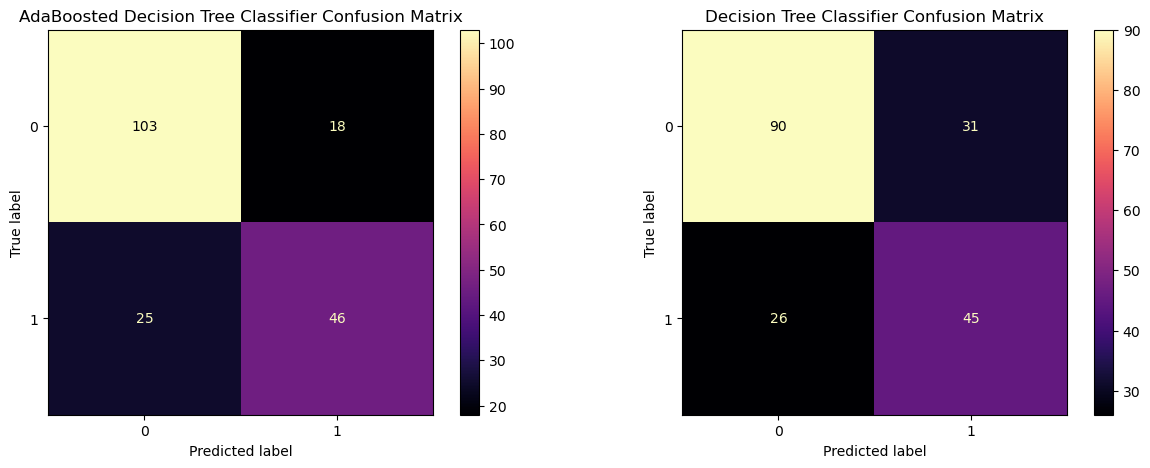

In [12]:
ada_y_pred = ada_clf.predict(X_test)
dt_y_pred = dt_clf.predict(X_test)

fig, axes = plt.subplots(1,2, figsize=(15,5))

ConfusionMatrixDisplay.from_predictions(y_test, ada_y_pred, cmap = 'magma', ax=axes[0])
axes[0].set_title("AdaBoosted Decision Tree Classifier Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, dt_y_pred, cmap = 'magma', ax=axes[1])
axes[1].set_title("Decision Tree Classifier Confusion Matrix")
plt.show()

### F1 Comparison
As we can see from these F1 scores, the Ada Boosted Classifier gives better results than a normal decision classifier.

In [9]:
print("The F1 score with weighted average of AdaBoostedClassifier is: " + str(f1_score(y_test, ada_y_pred, average='weighted')) )
print("The F1 score with weighted average of DecisionTreeClassifier is: " + str(f1_score(y_test, dt_y_pred, average='weighted')) )

The F1 score with weighted average of AdaBoostedClassifier is: 0.7733833482076453
The F1 score with weighted average of DecisionTreeClassifier is: 0.7050423017308188


### F1 change with learning_rate and n_estimators
Below, we plot how the f1 score changes as we vary the number of estimators, and the learning rate

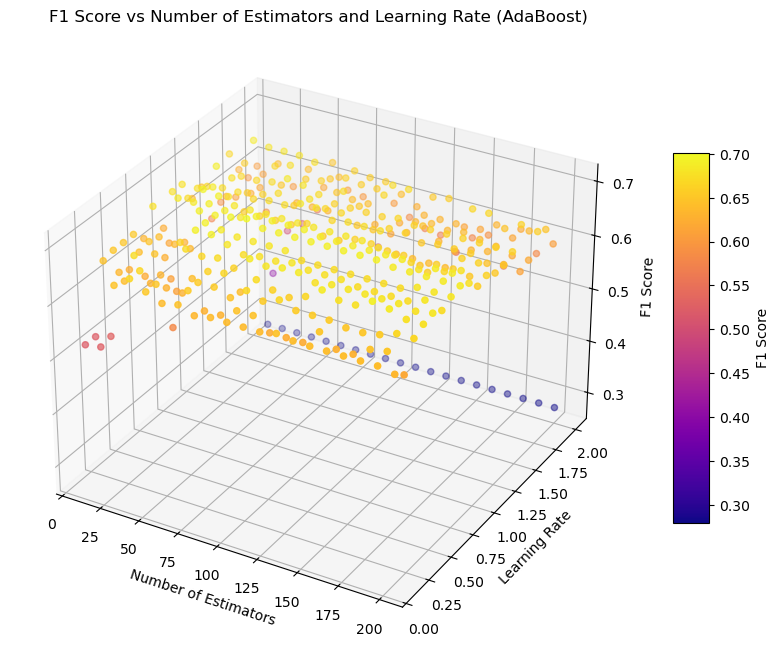

In [10]:
# Define the ranges of hyperparameters
n_estimators_range = range(10, 201, 10)         # 10 to 200 estimators
learning_rates = np.linspace(0.1, 2.0, 20)      # 20 values from 0.1 to 2.0

# Lists to store combinations and F1 scores
n_estimators_list = []
learning_rate_list = []
f1_scores = []

# Loop over grid of hyperparameters
for n_est in n_estimators_range:
    for lr in learning_rates:
        clf = DecisionTreeClassifier(max_depth=1, random_state=12)
        ada_clf = AdaBoostClassifier(
            clf,
            n_estimators=n_est,
            algorithm='SAMME',
            learning_rate=lr
        )
        ada_clf.fit(X_train, y_train)
        y_pred = ada_clf.predict(X_test)
        f1 = f1_score(y_test, y_pred)

        n_estimators_list.append(n_est)
        learning_rate_list.append(lr)
        f1_scores.append(f1)

# Convert lists to numpy arrays for plotting
n_estimators_arr = np.array(n_estimators_list)
learning_rate_arr = np.array(learning_rate_list)
f1_arr = np.array(f1_scores)

# Plot 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    n_estimators_arr, learning_rate_arr, f1_arr,
    c=f1_arr, cmap='plasma', marker='o'
)

ax.set_title("F1 Score vs Number of Estimators and Learning Rate (AdaBoost)")
ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Learning Rate")
ax.set_zlabel("F1 Score")

fig.colorbar(scatter, ax=ax, shrink=0.6, aspect=10, label='F1 Score')
plt.show()